# TrueRide Bicycles (TRB) Sales, Customer & Product Analysis

**Goal:** turn 4 years of TRB transaction data (Q4 2020–Q1 2024) into a customer segmentation model (RFM),
a product performance view, and a profitability breakdown that leadership can act on.

**Structure of this notebook:**
1. Load & prepare data
2. Build the master transaction dataset
3. Exploratory check: commute distance vs. spending
4. RFM feature engineering
5. RFM scoring (1–5 scale per dimension)
6. Customer segmentation
7. Segment-level profiling
8. Customer demographics by segment
9. Export: customer-level segment table
10. Product performance analysis
11. Revenue & profit analysis
12. Price segmentation


## 1. Load & Prepare Data

In [2]:
# Import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Reference date used throughout for "days since last order" calculations.
# Matches the cutoff used in the original TRB dataset.
TODAY = pd.to_datetime('2024-12-30')

DATA_PATH = 'DESCRIPTION + FILES/TRB Dataset.xlsx'  # using local path

In [3]:
# Orders: force key columns to string so they behave as IDs, not numbers
order_dtypes = {
    'ProductKey': str,
    'CustomerKey': str,
    'PromotionKey': str
}
Order = pd.read_excel(DATA_PATH, sheet_name='Orders', dtype=order_dtypes)
Order.head()

,ProductKey,OrderDate,DueDate,ShipDate,CustomerKey,PromotionKey,SalesTerritoryCountry,SalesTerritoryGroup,SalesOrderNumber,SalesOrderLineNumber,UnitPrice,ProductStandardCost,SalesAmount,TaxAmt
0,310,2020-12-27,2021-01-08,2021-01-03,21768,1,United states,North America,SO43697,1,3936.09700,2388.42362,3936.09700,28.62616
1,346,2020-12-27,2021-01-08,2021-01-03,28389,1,Italy,Europe,SO43698,1,3739.98900,2103.36984,3739.98900,27.19992
2,346,2020-12-27,2021-01-08,2021-01-03,25863,1,Canada,North America,SO43699,1,3739.98900,2103.36984,3739.98900,27.19992
3,336,2020-12-27,2021-01-08,2021-01-03,14501,1,Canada,North America,SO43700,1,769.00802,454.46093,769.00802,5.59279
4,346,2020-12-27,2021-01-08,2021-01-03,11003,1,New Zealand,Pacific,SO43701,1,3739.98900,2103.36984,3739.98900,27.19992


In [4]:
# Products: same step as Orders
product_dtypes = {'ProductKey': str}
Product = pd.read_excel(DATA_PATH, sheet_name='Products', dtype=product_dtypes)
Product.dtypes

ProductKey              object
ProductAlternateKey     object
ProductName             object
ProductSubcategory      object
ProductCategoryName     object
StandardCost           float64
Color                   object
ListPrice              float64
Size                    object
SizeRange               object
Weight                 float64
ProductLine             object
Class                   object
Style                   object
ModelName               object
Description             object
dtype: object

In [5]:
# Customers
customer_dtypes = {'CustomerKey': str}
Customer = pd.read_excel(DATA_PATH, sheet_name='Customers', dtype=customer_dtypes)
Customer.head()

,CustomerKey,Title,FirstName,LastName,BirthDate,MaritalStatus,Gender,EmailAddress,YearlyIncome,TotalChildren,NumberChildrenAtHome,EnglishEducation,EnglishOccupation,HouseOwnerFlag,DateFirstPurchase,CommuteDistance
0,11000,NaN,Jon,Yang,1990-03-14 07:40:48,Married,Male,jon24@adventure-works.com,99000.0,2,0,Bachelors,Professional,Y,2021-01-17,1-2 Miles
1,11001,NaN,Eugene,Huang,1995-07-12 19:12:00,Single,Male,eugene10@adventure-works.com,66000.0,3,3,Bachelors,Professional,N,2021-01-13,0-1 Miles
2,11002,NaN,Ruben,Torres,1989-06-10 01:55:12,Married,Male,ruben35@adventure-works.com,66000.0,3,3,Bachelors,Professional,Y,2021-01-05,2-5 Miles
3,11003,NaN,Christy,Zhu,1992-05-08 19:12:00,Single,Female,christy12@adventure-works.com,77000.0,0,0,Bachelors,Professional,N,2016-12-27,5-10 Miles
4,11004,NaN,Elizabeth,Johnson,1999-04-13 22:04:48,Single,Female,elizabeth5@adventure-works.com,88000.0,5,5,Bachelors,Professional,Y,2021-01-21,1-2 Miles


In [6]:
# Promotions (not used in this version of the analysis — kept for completeness / future work)
Promotion = pd.read_excel(DATA_PATH, sheet_name='Promotion')
Promotion.head()

,PromotionKey,EnglishPromotionName,DiscountPercent,EnglishPromotionType,PromotionCategory
0,1,No Discount,0.00,No Discount,No Discount
1,2,Volume Discount 11 to 14,0.02,Volume Discount,Reseller
2,3,Volume Discount 15 to 24,0.05,Volume Discount,Reseller
3,4,Volume Discount 25 to 40,0.10,Volume Discount,Reseller
4,5,Volume Discount 41 to 60,0.15,Volume Discount,Reseller


## 2. Data Intergration: the Master Transaction Dataset

One row per order line, joined with customer and product attributes. This is the base table most of the analysis below builds from.

In [7]:
master_df = (
    Order
    .merge(Customer, on='CustomerKey', how='left')
    .merge(Product, on='ProductKey', how='left')
)
master_df.shape

(60398, 44)

## 3. Explanatory Data Analysis:

**Commute Distance vs. Spending**

Quick sanity check on whether customers who commute further tend to spend more (e.g. on higher-end bikes).
Not part of the core segmentation, but worth ruling in/out early.

In [ ]:
distance_map = {
    '0-1 Miles': 0,
    '1-2 Miles': 1,
    '2-5 Miles': 2,
    '5-10 Miles': 5,
    '10+ Miles': 10
}
master_df['CommuteDistanceNumeric'] = master_df['CommuteDistance'].map(distance_map)

commute_sales_corr = master_df['CommuteDistanceNumeric'].corr(master_df['SalesAmount'])
print(f"Correlation between commute distance and sales amount: {commute_sales_corr:.3f}")

**Result:** the correlation is weak >> commute distance isn't a meaningful driver of spend at TRB. Not pursued further.

## 4. RFM Feature Engineering

Calculate the three raw RFM inputs per customer:
- **Recency**: days since their most recent order (lower = more recent = better)
- **Frequency**: total number of orders placed
- **Monetary**: total amount spent

`ASSUMPTION`: TRB is a consumer-durable / high-ticket business (bikes are infrequent, high-value purchases), so Recency and
Monetary carry more segmentation weight than Frequency so that assumption shapes the segment rules in Section 6.

In [8]:
# Create rfm comparision
rfm_raw = Order.groupby('CustomerKey').agg(
    Frequency=('ProductKey', 'count'),
    Recency=('OrderDate', lambda d: (TODAY - d.max()).days),
    Monetary=('SalesAmount', 'sum')
).reset_index()

rfm_raw.head()

,CustomerKey,Frequency,Recency,Monetary
0,11000,8,608,9073.889
1,11001,11,387,7022.268
2,11002,4,677,8925.444
3,11003,9,601,8953.219
4,11004,6,610,9015.611


## 5. RFM Scoring

Convert each raw RFM value into a 1–5 score using quintiles, so customers can be compared on a common scale regardless of the underlying unit (days vs. order count vs. dollars). Assuming we assigned 3 equal weight for 3 factors.

- **Recency** is scored in reverse because of the logic of the *most recent* customers (lowest day count) getting the *highest* score (5).
- **Frequency** and **Monetary** are scored foward, means higher values get higher scores.

In [9]:
# Cutting-point
quintile_edges = [0, 0.2, 0.4, 0.6, 0.8, 1]
# Create a copy of related table
RFM = rfm_raw.copy()

# Recency: most recent customers score highest, so labels are reversed (5 -> 1)
RFM['R_score'] = pd.qcut(RFM['Recency'], q=quintile_edges, labels=[5, 4, 3, 2, 1], duplicates='drop').astype(int)

# Frequency & Monetary: highest values score highest (qcut labels start at 0, so add 1 to rebase to 1-5)
RFM['F_score'] = (pd.qcut(RFM['Frequency'], q=quintile_edges, labels=False, duplicates='drop') + 1).astype(int)
RFM['M_score'] = (pd.qcut(RFM['Monetary'], q=quintile_edges, labels=False, duplicates='drop') + 1).astype(int)

RFM['RFM_score'] = RFM['R_score'] + RFM['F_score'] + RFM['M_score']
RFM.head()

,CustomerKey,Frequency,Recency,Monetary,R_score,F_score,M_score,RFM_score
0,11000,8,608,9073.889,2,4,5,11
1,11001,11,387,7022.268,5,4,5,14
2,11002,4,677,8925.444,1,3,5,9
3,11003,9,601,8953.219,2,4,5,11
4,11004,6,610,9015.611,2,4,5,11


### Recency score distribution

- At Patch, we consider the duration beyond 365 days to be a potentially "churned" customer. 
    - The 5-scored band covers customers who ordered 318–410 days ago (~20.4% of customers)
    - The 1-scored band covers 626–1,464 days (~19.9%) 
>> TRB's longest-inactive customers.

In [10]:
r_score_dist = (
    RFM['R_score']
    .value_counts()
    .sort_index()
    .rename_axis('R_score')
    .reset_index(name='Count')
)
r_score_dist['Percentage'] = (r_score_dist['Count'] / r_score_dist['Count'].sum() * 100).round(2)
r_score_dist

,R_score,Count,Percentage
0,1,3680,19.91
1,2,3712,20.08
2,3,3690,19.96
3,4,3633,19.65
4,5,3769,20.39


### Frequency score distribution

- Score #1 (lowest: 1–2 orders) covers ~41% of customers
- Score #4 (5–68 orders) covers ~18%  
>> TRB's repeat/loyal buyers are a clear minority of the base.

In [11]:
f_score_dist = (
    RFM['F_score']
    .value_counts()
    .sort_index()
    .rename_axis('F_score')
    .reset_index(name='Count')
)
f_score_dist['Percentage'] = (f_score_dist['Count'] / f_score_dist['Count'].sum() * 100).round(2)
f_score_dist

,F_score,Count,Percentage
0,1,7600,41.12
1,2,4622,25.01
2,3,2852,15.43
3,4,3410,18.45


## 6. Customer Segmentation

Segment definitions, weighted toward Recency and Monetary per the high-ticket/low-frequency assumption above:

| Segment | Rule | Logic |
|---|---|---|
| Most Valuable | R≥4, F≥3, M≥4 | Recent, frequent, and high-spending =>> top revenue contributors |
| Loyal | F=4 and R≥4 | Frequent, recent repeat buyers =>> high lifetime value even if per-order spend is lower |
| Big Spenders | M≥4 | High-value transactions regardless of frequency |
| New Customers | R=5 and F≤2 | Recent first-time or early-stage buyers |
| Churned Customer | R=1, F=1, M=1 | Lowest score on all three dimensions =>> effectively inactive |
| At Risk | R≤3, F≤2, M≤3 | Below-average across the board =>> a large group worth monitoring for further drop-off |
| Others | *(none of the above)* | Doesn't cleanly fit a named segment |

In [ ]:
# Assign name for each customer basket based on the logic 
def segment_customer(row):
    if row['R_score'] >= 4 and row['F_score'] >= 3 and row['M_score'] >= 4:
        return 'Most Valuable'
    elif row['F_score'] == 4 and row['R_score'] >= 4:
        return 'Loyal'
    elif row['M_score'] >= 4:
        return 'Big Spenders'
    elif row['R_score'] == 5 and row['F_score'] <= 2:
        return 'New Customers'
    elif row['R_score'] == 1 and row['F_score'] == 1 and row['M_score'] == 1:
        return 'Churned Customer'
    elif row['R_score'] <= 3 and row['F_score'] <= 2 and row['M_score'] <= 3:
        return 'At Risk'
    else:
        return 'Others'

RFM['Segment'] = RFM.apply(segment_customer, axis=1)
RFM['Segment'].value_counts()

Segment
Big Spenders        5789
At Risk             4631
Others              3354
New Customers       1614
Most Valuable       1584
Loyal                757
Churned Customer     755
Name: count, dtype: int64

## 7. Segment-Level Profiling

How many customers sit in each segment, how much they spend on average, and what share of total revenue they represent.

In [13]:
# Customer Segment Profitability analysis 
segment_summary = RFM.groupby('Segment').agg(
    CustomerCount=('CustomerKey', 'count'),
    AverageSpending=('Monetary', 'mean'),
    TotalSpending=('Monetary', 'sum')
).round(2)

segment_summary['PctOfCustomers'] = (segment_summary['CustomerCount'] / segment_summary['CustomerCount'].sum() * 100).round(2)
segment_summary['PctOfTotalSpending'] = (segment_summary['TotalSpending'] / segment_summary['TotalSpending'].sum() * 100).round(2)
segment_summary['PctOfAvgSpending'] = (segment_summary['AverageSpending'] / segment_summary['AverageSpending'].sum() * 100).round(2)

segment_summary = segment_summary.sort_values('TotalSpending', ascending=False)
segment_summary['CumulativePctOfSpending'] = segment_summary['PctOfTotalSpending'].cumsum().round(2)

segment_summary

,CustomerCount,AverageSpending,TotalSpending,PctOfCustomers,PctOfTotalSpending,PctOfAvgSpending,CumulativePctOfSpending
Segment,,,,,,,
Big Spenders,5789,3883.15,22479556.62,31.32,69.61,40.48,69.61
Most Valuable,1584,4891.46,7748068.30,8.57,23.99,50.99,93.60
At Risk,4631,185.75,860201.95,25.05,2.66,1.94,96.26
Others,3354,231.11,775158.76,18.15,2.40,2.41,98.66
New Customers,1614,149.02,240524.98,8.73,0.74,1.55,99.40
Loyal,757,227.79,172438.12,4.10,0.53,2.37,99.93
Churned Customer,755,24.63,18596.22,4.08,0.06,0.26,99.99


**Takeaways:**

| Segment | Takeaway |
|---|---|
| Most Valuable | Together with `Big Spenders`, this minority of customers drives the large majority of total revenue, we have clue that TRB's revenue is concentrated, not evenly spread. |
| Big Spenders | Same as above was combined, these two segments account for 93.60% of revenue from just 39.89% of customers. |
| Loyal | customers repeat-purchase often but at lower order values, so their *average* spend looks unremarkable so their value shows up in resilience (see the README business narrative), not in per-order size.|
| At Risk | is a sizeable share of the customer base with non-trivial historical spend. This is a natural retention target before those customers fully churn.|

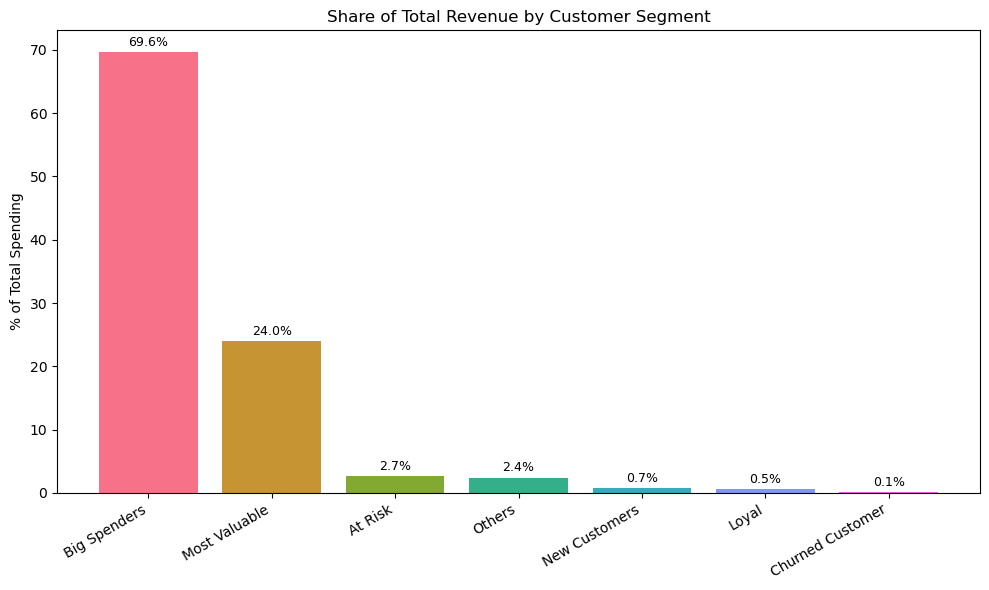

In [14]:
# Plot the total share of revenue generated by each segment 
fig, ax = plt.subplots(figsize=(10, 6))
sorted_summary = segment_summary.sort_values('PctOfTotalSpending', ascending=False)

bars = ax.bar(sorted_summary.index, sorted_summary['PctOfTotalSpending'], color=sns.color_palette('husl', len(sorted_summary)))
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height + 0.5, f'{height:.1f}%', ha='center', va='bottom', fontsize=9)

ax.set_ylabel('% of Total Spending')
ax.set_title('Share of Total Revenue by Customer Segment')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## 8. Customer Demographics

Specialization for marketing strategy to explore the customer profile, including Age and income profile of the customer base, using the RFM segment assignments joined back to customer records.

In [15]:
# Create the customer records from RFM logics
customer_profile = RFM.merge(Customer, on='CustomerKey', how='left')

customer_profile['BirthDate'] = pd.to_datetime(customer_profile['BirthDate'])
today = datetime.today()
customer_profile['Age'] = customer_profile['BirthDate'].apply(
    lambda dob: today.year - dob.year - ((today.month, today.day) < (dob.month, dob.day))
).astype(int)

customer_profile['Age'].describe()

count    18484.000000
mean        38.742372
std         13.366251
min         19.000000
25%         28.000000
50%         36.000000
75%         48.000000
max        100.000000
Name: Age, dtype: float64

**Age**

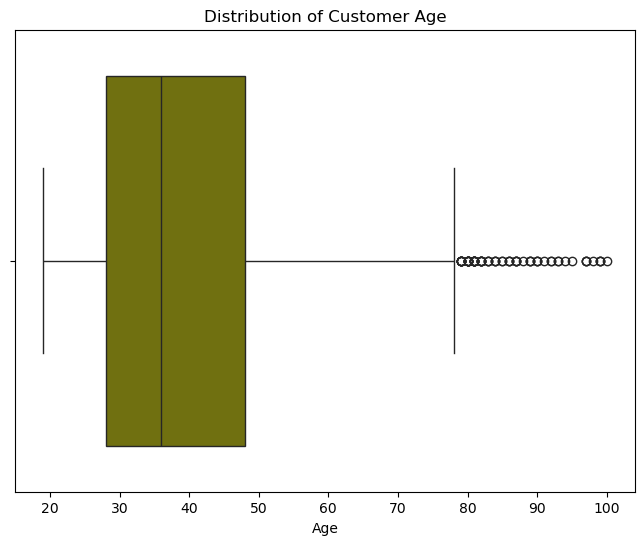

In [ ]:
# Plot distribution for Age
plt.figure(figsize=(8, 6))
sns.boxplot(x=customer_profile['Age'], color='olive')
plt.title('Distribution of Customer Age')
plt.xlabel('Age')
plt.show()

**YearlyIcome**

In [17]:
customer_profile['YearlyIncome'].describe()

count     18484.000000
mean      63036.355767
std       35514.425873
min       11000.000000
25%       33000.000000
50%       66000.000000
75%       77000.000000
max      187000.000000
Name: YearlyIncome, dtype: float64

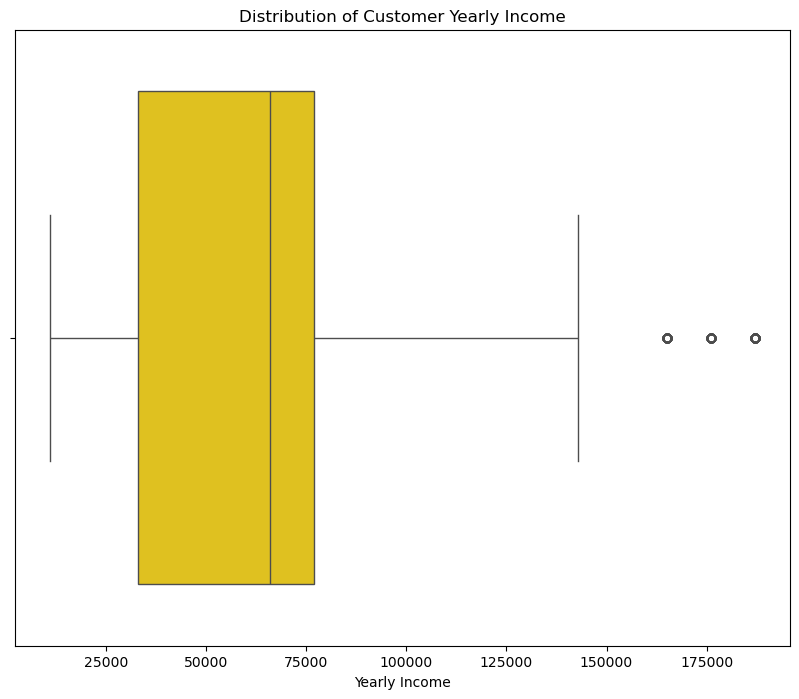

In [18]:
plt.figure(figsize=(10, 8))
sns.boxplot(x=customer_profile['YearlyIncome'], color='gold')
plt.title('Distribution of Customer Yearly Income')
plt.xlabel('Yearly Income')
plt.show()

## 9. Export: Customer-Level Segment Table

Final customer-level table (RFM scores + segment + demographics), exported for ready-to-use version in Tableau.

In [19]:
customer_profile.to_csv('Customer_analysis.csv', index=False)
customer_profile.head()

,CustomerKey,Frequency,Recency,Monetary,R_score,F_score,M_score,RFM_score,Segment,Title,...,EmailAddress,YearlyIncome,TotalChildren,NumberChildrenAtHome,EnglishEducation,EnglishOccupation,HouseOwnerFlag,DateFirstPurchase,CommuteDistance,Age
0,11000,8,608,9073.889,2,4,5,11,Big Spenders,NaN,...,jon24@adventure-works.com,99000.0,2,0,Bachelors,Professional,Y,2021-01-17,1-2 Miles,36
1,11001,11,387,7022.268,5,4,5,14,Most Valuable,NaN,...,eugene10@adventure-works.com,66000.0,3,3,Bachelors,Professional,N,2021-01-13,0-1 Miles,31
2,11002,4,677,8925.444,1,3,5,9,Big Spenders,NaN,...,ruben35@adventure-works.com,66000.0,3,3,Bachelors,Professional,Y,2021-01-05,2-5 Miles,37
3,11003,9,601,8953.219,2,4,5,11,Big Spenders,NaN,...,christy12@adventure-works.com,77000.0,0,0,Bachelors,Professional,N,2016-12-27,5-10 Miles,34
4,11004,6,610,9015.611,2,4,5,11,Big Spenders,NaN,...,elizabeth5@adventure-works.com,88000.0,5,5,Bachelors,Professional,Y,2021-01-21,1-2 Miles,27


## 10. Product Performance Analysis

Final part: Which products sell the most overall, and which products each customer segment favours.
> this is what connects the customer-level story back to the product/inventory decisions in the README recommendations.

In [20]:
# Merge Order and Product table
product_orders = Order.merge(Product, on='ProductKey', how='left')

# List the product by customer segment
product_by_segment = (
    product_orders
    .merge(customer_profile[['CustomerKey', 'Segment']], on='CustomerKey', how='left')
    [['ProductKey', 'OrderDate', 'CustomerKey', 'ProductName', 'ProductSubcategory',
      'ProductCategoryName', 'Segment', 'SalesAmount']]
)

# Drop exact duplicate transactions: same customer, same product, same order date
before = len(product_by_segment)
product_by_segment = product_by_segment.drop_duplicates(subset=['CustomerKey', 'ProductName', 'OrderDate'])
print(f"Removed {before - len(product_by_segment)} duplicate transaction rows")

product_by_segment.head()

Removed 7 duplicate transaction rows


,ProductKey,OrderDate,CustomerKey,ProductName,ProductSubcategory,ProductCategoryName,Segment,SalesAmount
0,310,2020-12-27,21768,"Road-150 Red, 62",Road Bikes,Bikes,Big Spenders,3936.09700
1,346,2020-12-27,28389,"Mountain-100 Silver, 44",Mountain Bikes,Bikes,Big Spenders,3739.98900
2,346,2020-12-27,25863,"Mountain-100 Silver, 44",Mountain Bikes,Bikes,Big Spenders,3739.98900
3,336,2020-12-27,14501,"Road-650 Black, 62",Road Bikes,Bikes,Big Spenders,769.00802
4,346,2020-12-27,11003,"Mountain-100 Silver, 44",Mountain Bikes,Bikes,Big Spenders,3739.98900


In [21]:
# List top 10 products most popular
top_products_overall = (
    product_by_segment.groupby('ProductKey')['SalesAmount']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)
top_products_overall.head(10)

,ProductKey,SalesAmount
0,312,1326464.689
1,310,1322528.592
2,313,1188701.294
3,314,1161148.615
4,311,1106043.257
5,361,1077956.803
6,353,1076939.358
7,363,1057760.891
8,359,1050187.424
9,357,1023347.589


In [ ]:
# Map each top selling product by each Segment
top_products_by_segment = (
    product_by_segment.groupby(['Segment', 'ProductSubcategory'])['SalesAmount']
    .sum()
    .reset_index()
    .sort_values(['Segment', 'SalesAmount'], ascending=[True, False])
    .groupby('Segment')
    .head(10)
)
top_products_by_segment

,Segment,ProductSubcategory,SalesAmount
11,At Risk,Road Bikes,487926.59839
15,At Risk,Touring Bikes,80841.91500
14,At Risk,Tires and Tubes,61315.01200
10,At Risk,Mountain Bikes,51973.60300
7,At Risk,Helmets,44955.15200
...,...,...,...
102,Others,Jerseys,40731.72400
105,Others,Shorts,15474.78900
94,Others,Bike Stands,14166.90000
95,Others,Bottles and Cages,13408.80200


In [ ]:
product_by_segment.to_csv('Product_by_segment.csv', index=False)

## 11. Revenue & Profit Analysis

Profit per order line, and a regional breakdown.
> This is the base data behind the "best sales year vs. best profit year" and regional-gap findings in the README.

In [23]:
# Calculate the Profit from existing attributes
Order['Profit'] = Order['SalesAmount'] - Order['ProductStandardCost'] - Order['TaxAmt']

# Map regions 
regional_summary = Order.groupby('SalesTerritoryCountry').agg(
    OrderCount=('SalesOrderNumber', 'nunique'),
    TotalSales=('SalesAmount', 'sum'),
    TotalProfit=('Profit', 'sum')
).sort_values('TotalSales', ascending=False).round(2)

regional_summary

,OrderCount,TotalSales,TotalProfit
SalesTerritoryCountry,,,
Canada,9567,10328768.46,4215960.57
New Zealand,6718,9967100.64,3981952.58
Spain,3031,3730883.43,1502406.16
Belgium,2484,3183743.57,1282953.34
Italy,2484,2908419.49,1173739.05
United states,3375,2175629.35,897090.89


In [ ]:
tax_sales_corr = Order['SalesAmount'].corr(Order['TaxAmt'])
print(f"Correlation between sales amount and tax amount: {tax_sales_corr:.3f}")
# Expected to be strongly positive since tax is calculated as a function of sales amount. But the absolute correlation need further data sanity check before moving on

Correlation between sales amount and tax amount: 1.000


In [ ]:
Order.to_csv('Order_with_profit.csv', index=False)

## 12. Price Segmentation

Bin products into price tiers to see where TRB's catalogue sits and which tier drives the most transactions.
Bin edges are based on the observed quartile breaks in `ListPrice`.

In [25]:
price_view = Order.merge(Product, on='ProductKey', how='left')
price_view['ListPrice'].describe()

count    60398.000000
mean       534.695602
std       1021.338881
min          2.519000
25%          8.745000
50%         32.989000
75%        593.989000
max       3936.097000
Name: ListPrice, dtype: float64

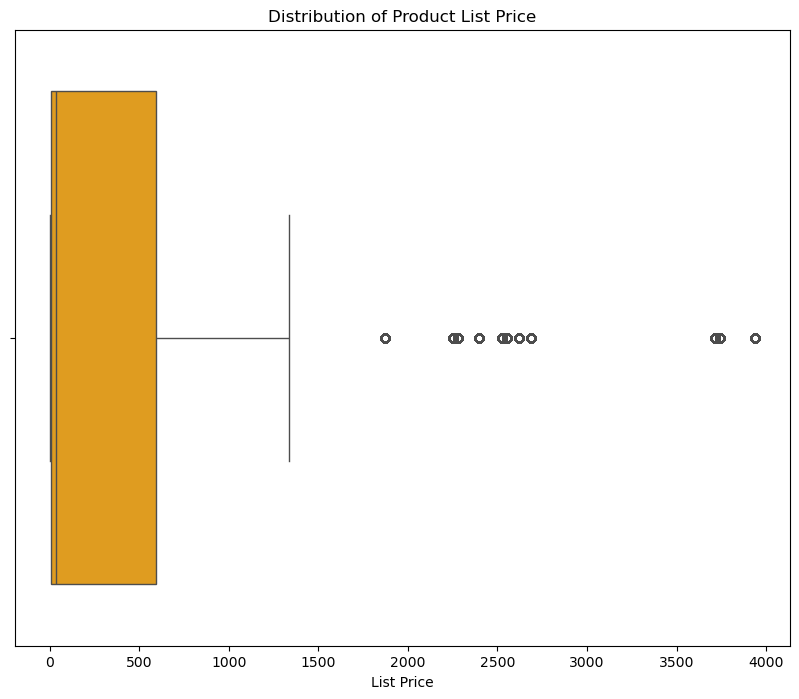

In [26]:
plt.figure(figsize=(10, 8))
sns.boxplot(x=price_view['ListPrice'], color='orange')
plt.title('Distribution of Product List Price')
plt.xlabel('List Price')
plt.show()

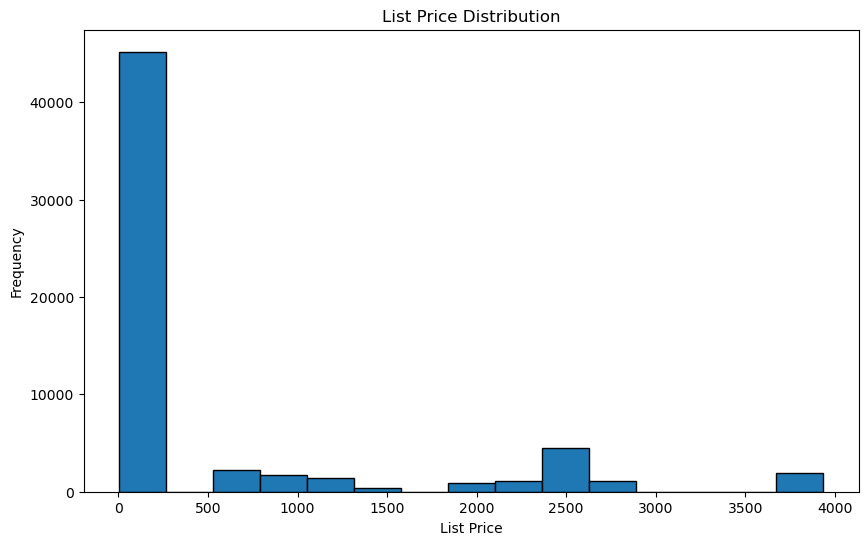

In [27]:
plt.figure(figsize=(10, 6))
plt.hist(price_view['ListPrice'], bins=15, edgecolor='black')
plt.title('List Price Distribution')
plt.xlabel('List Price')
plt.ylabel('Frequency')
plt.show()

In [28]:
price_view['PriceSegment'] = pd.cut(
    price_view['ListPrice'],
    bins=[0, 33, 590, 1300, float('inf')],
    labels=['Low-end', 'Mid-range', 'High-end', 'Premium']
)

price_view[['ProductKey', 'CustomerKey', 'ProductName', 'ListPrice', 'SalesAmount', 'PriceSegment']].head(20)

,ProductKey,CustomerKey,ProductName,ListPrice,SalesAmount,PriceSegment
0,310,21768,"Road-150 Red, 62",3936.09700,3936.09700,Premium
1,346,28389,"Mountain-100 Silver, 44",3739.98900,3739.98900,Premium
2,346,25863,"Mountain-100 Silver, 44",3739.98900,3739.98900,Premium
3,336,14501,"Road-650 Black, 62",769.00802,769.00802,High-end
4,346,11003,"Mountain-100 Silver, 44",3739.98900,3739.98900,Premium
5,311,27645,"Road-150 Red, 44",3936.09700,3936.09700,Premium
6,310,16624,"Road-150 Red, 62",3936.09700,3936.09700,Premium
7,351,11005,"Mountain-100 Black, 48",3712.48900,3712.48900,Premium
8,344,11011,"Mountain-100 Silver, 38",3739.98900,3739.98900,Premium
9,312,27621,"Road-150 Red, 48",3936.09700,3936.09700,Premium
